# Plot karyoPlots

1) Extended Errors
2) Genomic Features

In [2]:
library(tidyverse)
library(karyoploteR)
library(Biostrings)

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘karyoploteR’ was built under R version 4.4.2”
Loading required package: regioneR

Warning message:
“package ‘regioneR’ was built under R version 4.4.2”
Loading required package: GenomicRanges

Warning message:
“package ‘GenomicRanges’ was built under R version 4.4.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGener

# Extended QC

In [3]:
# Assmbly fasta
fa = "../../assembly/output/verkko/TUE_02_02UL_old/assembly.fasta"

# load beds
nucflag_status = "../../analysis_other/nucflag/TUE_02_03UL.nucflag_misasm.bed"
gap_stats = "../../assembly/qc/phased_verkko/TUE_02_03UL_old/gap_stats.both.n_regions.bed"
rm = "../../analysis_other/repeatmasker/TUE_02_03UL/rm_summary/TUE_02_03UL_simplified.bed"
colors = "../../assembly/qc/phased_verkko/TUE_02_03UL_old/colors.tsv"
telo = ""

Create custom genome from Assembly

In [4]:
# Read the fasta file
fasta_seqs <- readDNAStringSet(fa)

# Create a GRanges object with chromosome lengths
custom_genome <- GRanges(
  seqnames = names(fasta_seqs),
  ranges = IRanges(start = 1, end = width(fasta_seqs))
)

# Set the genome name
genome(custom_genome) <- "GE-MED-T2T00"

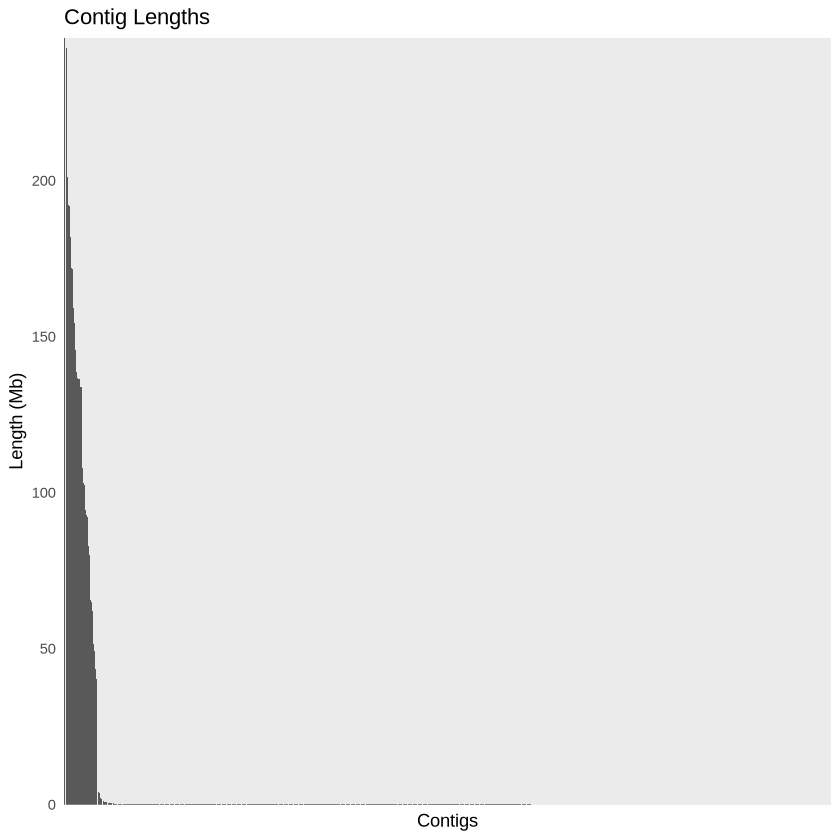

In [5]:
# Create data frame of contig lengths
contig_lengths <- data.frame(
  contig = names(fasta_seqs),
  length = width(fasta_seqs)
)

# Plot contig lengths
ggplot(contig_lengths, aes(x=reorder(contig, -length), y=length/1e6)) +
  geom_bar(stat="identity") +
  theme_minimal() +
  theme(axis.text.x = element_blank()) + 
  labs(x="Contigs", y="Length (Mb)", title="Contig Lengths") +
  scale_y_continuous(expand = c(0,0))


In [6]:
# Filter contigs > 10Mb and print their IDs
large_contigs <- contig_lengths[contig_lengths$length > 5e6,]
print("Contigs > 5Mb:")
print(large_contigs$contig)

[1] "Contigs > 5Mb:"
 [1] "haplotype1-0000001" "haplotype1-0000002" "haplotype1-0000003"
 [4] "haplotype1-0000004" "haplotype1-0000005" "haplotype1-0000006"
 [7] "haplotype1-0000007" "haplotype1-0000009" "haplotype1-0000010"
[10] "haplotype1-0000011" "haplotype1-0000012" "haplotype1-0000013"
[13] "haplotype1-0000014" "haplotype1-0000015" "haplotype1-0000016"
[16] "haplotype1-0000017" "haplotype1-0000019" "haplotype1-0000020"
[19] "haplotype1-0000021" "haplotype1-0000022" "haplotype1-0000023"
[22] "haplotype1-0000024" "haplotype1-0000026" "haplotype2-0000084"
[25] "haplotype2-0000087" "haplotype2-0000088" "haplotype2-0000090"
[28] "haplotype2-0000091" "haplotype2-0000093" "haplotype2-0000094"
[31] "haplotype2-0000095" "haplotype2-0000096" "haplotype2-0000097"
[34] "haplotype2-0000098" "haplotype2-0000099" "haplotype2-0000100"
[37] "haplotype2-0000101" "haplotype2-0000102" "haplotype2-0000103"
[40] "haplotype2-0000104" "haplotype2-0000105" "haplotype2-0000106"
[43] "haplotype2-0000107" "

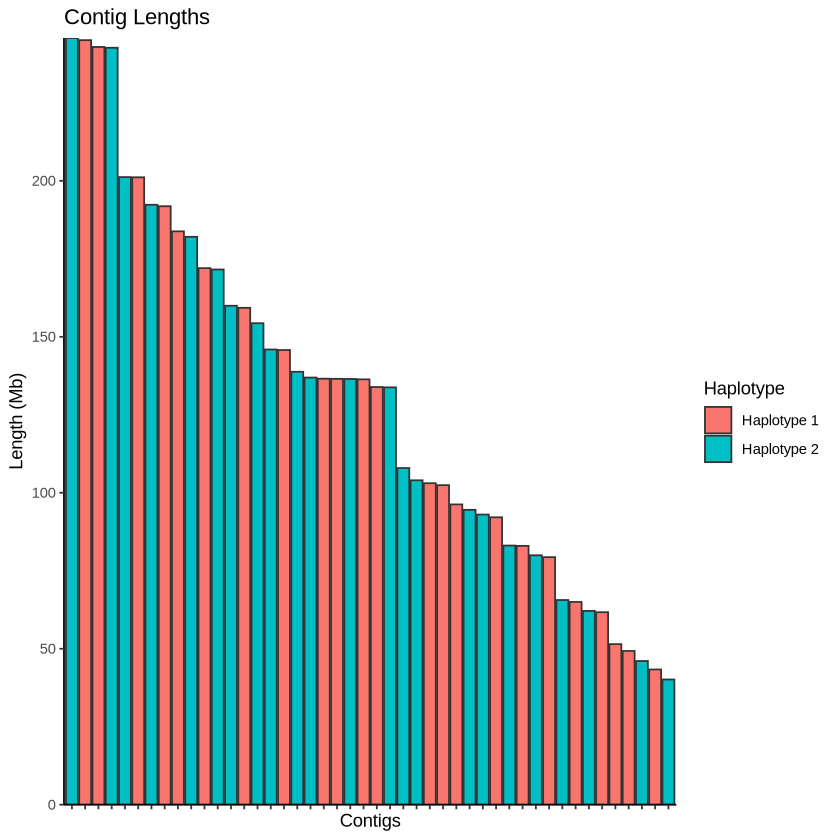

In [9]:
# Plot contig lengths
ggplot(large_contigs, aes(x=reorder(contig, -length), y=length/1e6, 
                         fill=ifelse(grepl("haplotype1", contig), "Haplotype 1",
                                   ifelse(grepl("haplotype2", contig), "Haplotype 2", "Other")))) +
  geom_bar(stat="identity", colour = "grey20") +
  theme_classic() +
  theme(axis.text.x = element_blank()) + 
  labs(x="Contigs", y="Length (Mb)", title="Contig Lengths", fill="Haplotype") +
  scale_y_continuous(expand = c(0,0))


In [1]:
large_contigs

ERROR: Error: object 'large_contigs' not found


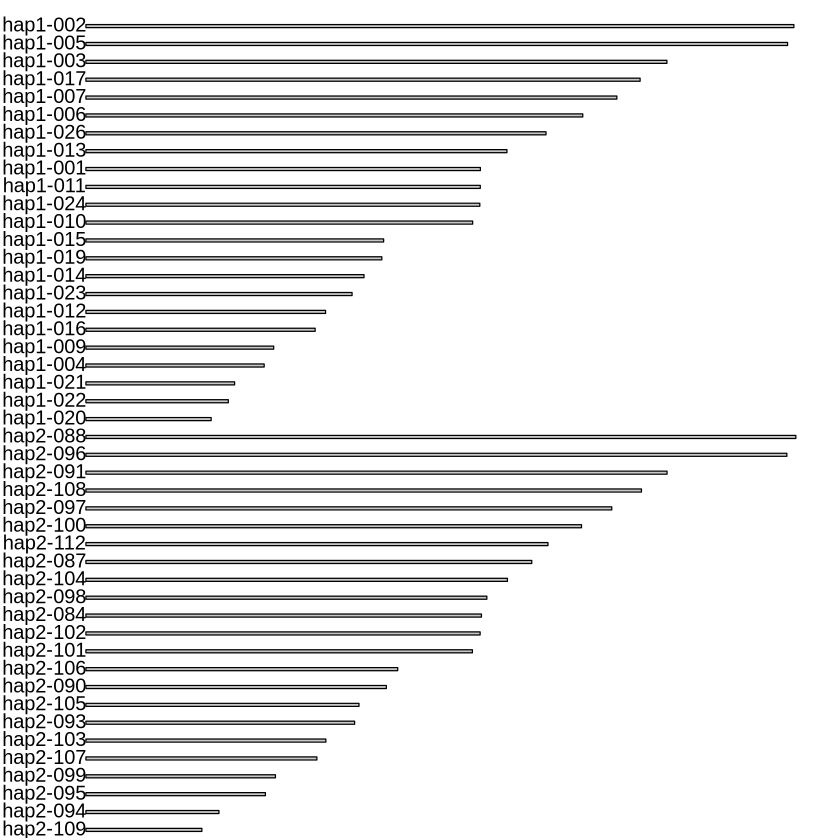

In [10]:
# Create a new genome with only large contigs and order by length and haplotype
large_seqs <- fasta_seqs[names(fasta_seqs) %in% large_contigs$contig]

# Create ordering based on length and haplotype
ordered_names <- names(large_seqs)[order(
  # First sort by haplotype (1, 2, then other)
  ifelse(grepl("haplotype1", names(large_seqs)), 1,
         ifelse(grepl("haplotype2", names(large_seqs)), 2, 3)),
  # Then by length (descending)
  -width(large_seqs)
)]

# Reorder sequences
large_seqs <- large_seqs[ordered_names]

# Simplify contig names by truncating haplotype and removing non-significant zeros
names(large_seqs) <- gsub("haplotype", "hap", names(large_seqs))
names(large_seqs) <- gsub("-0000", "-", names(large_seqs))


custom_genome_large <- toGRanges(data.frame(
  chr=names(large_seqs),
  start=1,
  end=width(large_seqs)
))
genome(custom_genome_large) <- "GE-MED-T2T00"

# Plot karyotype with ordered contigs
kp <- plotKaryotype(genome=custom_genome_large, chromosomes = "all")

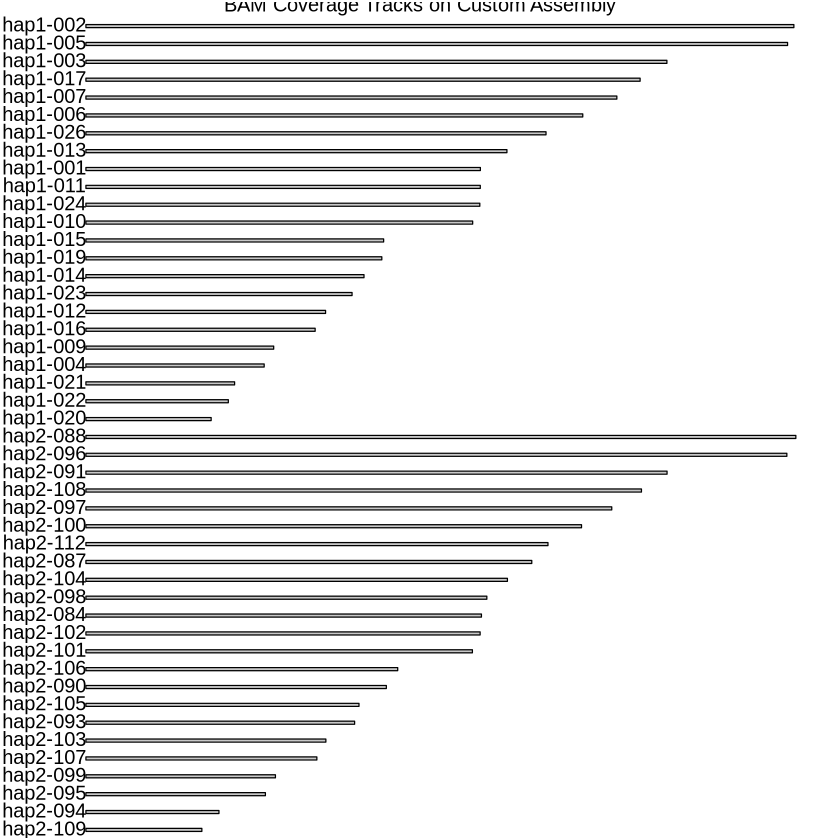

In [14]:
# Plot karyotype with ordered contigs
kp <- plotKaryotype(genome=custom_genome_large, chromosomes = "all")

# Load and plot nucflag status regions
nucflag_data <- toGRanges(read.table(nucflag_status, header=FALSE))
kpPlotRegions(kp, data=nucflag_data)

# Load and plot gap regions 
gap_data <- toGRanges(read.table(gap_stats, header=FALSE))
#kpPlotRegions(kp, data=gap_data, col="blue", border="blue", y0=0, y1=1, r0=0, r1=0.5, data.panel=1)

# Add title
kpAddMainTitle(kp, "BAM Coverage Tracks on Custom Assembly")

In [51]:
# Cell 1: Load libraries and source script
library(tidyverse)
source("../scripts/plot_genomic_features.R")

# Cell 2: Define input files
contig_file <- "assembly/qc/phased_verkko/TUE_02_03UL_old/contig_chromosome_assignments.tsv"
fai_file <- "reference/hg38.fa.fai"
feature_files <- c(
    "analysis_other/nucflag/TUE_02_03UL.nucflag_misasm.bed",
    "assembly/qc/phased_verkko/TUE_02_03UL_old/gap_stats.both.n_regions.bed",
    "analysis_other/repeatmasker/TUE_02_03UL/rm_summary/TUE_02_03UL_simplified.bed"
)
output_file <- "assembly/qc/phased_verkko/TUE_02_03UL_old/karyogram.pdf"

# Cell 3: Create plot
main(contig_file, fai_file, feature_files, output_file)

GRanges object with 51 ranges and 2 metadata columns:
               seqnames              ranges strand |          V4        V5
                  <Rle>           <IRanges>  <Rle> | <character> <integer>
   1 haplotype1-0000003 138530683-138538183      * |    N_region      7500
   2 haplotype1-0000003 156566351-156604837      * |    N_region     38486
   3 haplotype1-0000004   22843527-22851027      * |    N_region      7500
   4 haplotype1-0000004   26429069-26436569      * |    N_region      7500
   5 haplotype1-0000004   45800564-45808064      * |    N_region      7500
  ..                ...                 ...    ... .         ...       ...
  47 haplotype2-0000073     1393365-1400865      * |    N_region      7500
  48 haplotype2-0000074   34206741-34214241      * |    N_region      7500
  49 haplotype2-0000081   99012193-99112193      * |    N_region    100000
  50 haplotype2-0000085   11837236-11844736      * |    N_region      7500
  51 haplotype2-0000085   77481723-77489223   